Environment name: `r_env_corr`

In [ ]:
PATH_TO_FIGURES_SATAC <- paste0("figures/sATAC_preprocessing/", SATAC_SAMPLE_NAME, "/")
PATH_TO_FIGURES_VISIUM <- paste0("figures/Visium_preprocessing/", VISIUM_SAMPLE_NAME, "/")
PATH_TO_FIGURES_COMPARISON <- paste0("figures/integration_comparison/", SATAC_SAMPLE_NAME, "_&_", VISIUM_SAMPLE_NAME, "/")

PATH_TO_sATAC_PREPROCESSING_OUTPUT <- paste0("output/sATAC_preprocessing/", SATAC_SAMPLE_NAME, "/")
PATH_TO_VISIUM_PREPROCESSING_OUTPUT <- paste0("output/Visium_preprocessing/", VISIUM_SAMPLE_NAME, "/")

PATH_TO_sATAC_PREPROCESSING_OUTPUT_RDS <- paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "RDS_files/")
PATH_TO_VISIUM_PREPROCESSING_OUTPUT_RDS <- paste0(PATH_TO_VISIUM_PREPROCESSING_OUTPUT, "RDS_files/")

PATH_TO_VISIUM_CORRECTED_SPOTFILE <- paste0("output/Visium_preprocessing/", VISIUM_SAMPLE_NAME, "/", "correct_tissue_positions_list.csv")

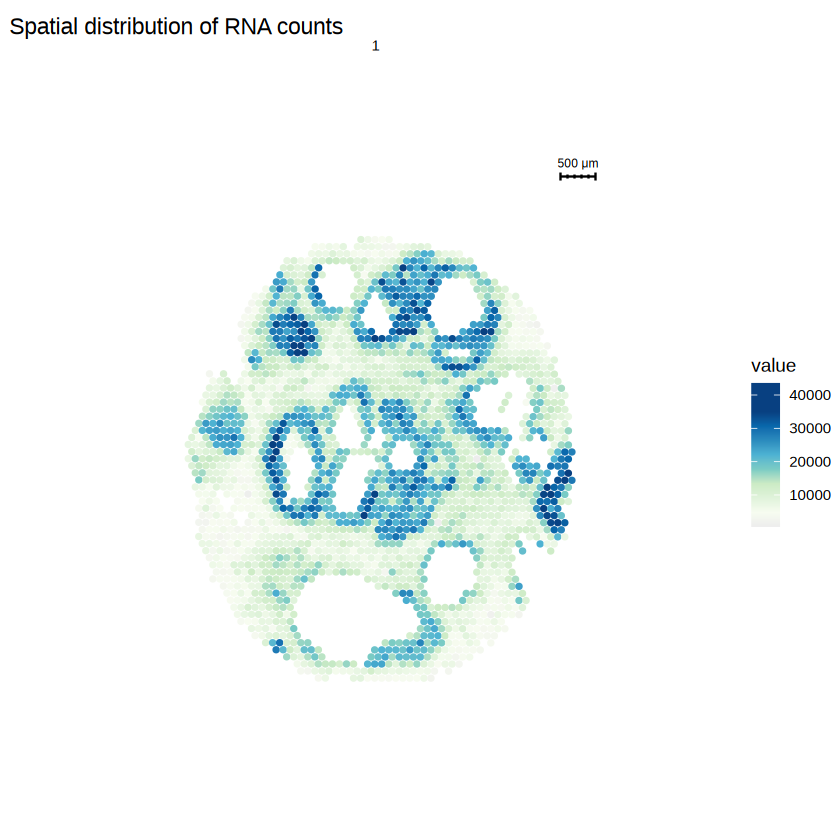

In [ ]:
# SpatialFeaturePlot(visium, features = "nCount_RNA") + theme(legend.position = "right")
# DefaultAssay(signac_selected) <- 'peaks'

png_plot_file_name <- paste0(PATH_TO_FIGURES_VISIUM, "Spatial_distribution_of_RNA_counts.png")
pdf_plot_file_name <- paste0(PATH_TO_FIGURES_VISIUM, "Spatial_distribution_of_RNA_counts.pdf")

pdf(file = pdf_plot_file_name, width = 5.7, height = 5)

p <- ST.FeaturePlot(visium, 
                'nCount_RNA', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.5) +
        ggtitle(paste("Spatial distribution of RNA counts"))+
        theme(plot.title = element_text(hjust = 0.5))

print(p)
dev.off()
ggsave(filename = png_plot_file_name, width = 5.7, height = 5, dpi = 300)
print(p)



png_plot_file_name <- paste0(PATH_TO_FIGURES_VISIUM, "dotplot_predictions_6kmeans_clusters_visium.png")
pdf_plot_file_name <- paste0(PATH_TO_FIGURES_VISIUM, "dotplot_predictions_6kmeans_clusters_visium.pdf")

pdf(file = pdf_plot_file_name, width = 8, height = 5, units = "in")

p <- DotPlot(visium, features = prediction_features, group.by = "kmeans_6", cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("ST cell type prediction scores on 6 K-Means clusters")

print(p)
dev.off()
ggsave(filename = png_plot_file_name, width = 8, height = 5, units = "in", dpi = 300)
print(p)

# 0. - Imports and paths

In [8]:
setwd(dir = "/disk2/user/gabgam/the_project/5_integration_and_correlation/")

In [1]:
suppressMessages(suppressWarnings(source("./utils/source_satac.R")))
library(biovizBase)
library(extrafont) # install.packages("extrafont")

Registering fonts with R



Loading the fonts.

In [2]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf 
# or, better, https://fonts.google.com/specimen/DM+Sans
# Import only DMSans-Medium
# font_import(paths = "../fonts/static/", prompt = FALSE, recursive = FALSE, pattern = "DMSans-Medium.ttf") # select just the Medium one
# loadfonts()  # Load registered fonts

# # verify if the font is available:
# fonts()

In [3]:
# # for font in Base R plots
# par(family = "DM Sans Medium")
# plot(1: 2, main = "Title in Custom Font")

sATAC sample paths.

In [4]:
PATH_TO_sATAC_DATA_FOLDER <- "../data/spatial_atac/"
PATH_sATAC_PREPROCESSING_OUTPUT <- "output/sATAC_preprocessing/"
PATH_TO_FIGURES <- "figures/sATAC_preprocessing/"

SELECTED_sATAC_SAMPLE <- "220327_C1"

# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
BRCA_PEAK_CALLS <- paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/BRCA_peakCalls.csv")

Visium sample paths.

In [5]:
PATH_TO_VISIUM_SAMPLE <- "../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
PATH_TO_VISIUM_MOD_SPOTFILES <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_VISIUM_SPOTFILE <- "output/Visium_preprocessing/FFPE_correct_tissue_positions_list.csv"
PATH_TO_VISIUM_HIGH_RES_IMAGE <- "../data/visium_ffpe/output_n_suppl_files/spatial/tissue_hires_image.png"
PATH_TO_VISIUM_JSON <- "../data/visium_ffpe/output_n_suppl_files/spatial/scalefactors_json.json"

# 3. - Loading the Visium assay

In [6]:
mod_spotfile <- read.csv(PATH_TO_VISIUM_MOD_SPOTFILES, row.names=1)
head(mod_spotfile)

,barcode,in_tissue,array_row,array_col,pxl_row,pxl_col,image_name,Cluster,R,G,B
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,AAACAACGAATAGTTC-1,0,0,16,3635,7471,,NA,NA,NA,NA
1,AAACAAGTATCTCCCA-1,1,50,102,16265,19934,,NA,NA,NA,NA
2,AAACAATCTACTAGCA-1,0,3,43,4395,11387,,NA,NA,NA,NA
3,AAACACCAATAACTGC-1,1,59,19,18526,7893,AAACACCAATAACTGC-1_row59_col19_100um.jpg,2,79,176,49
4,AAACAGAGCGACTCCT-1,1,14,94,7178,18782,AAACAGAGCGACTCCT-1_row14_col94_100um.jpg,4,59,163,236
5,AAACAGCTTTCAGAAG-1,1,43,9,14487,6446,AAACAGCTTTCAGAAG-1_row43_col9_100um.jpg,2,79,176,49


Choosing the overlapping spots by leveraging on the color chosen for the clustering. If there is no color, it means that the spot is not in tissue at all, or it was removed after the original processing.

In [7]:
table(mod_spotfile$in_tissue)


   0    1 
2474 2518 

In [9]:
temp_excluded_spots <- mod_spotfile$barcode[!is.na(mod_spotfile$cluster) | 
                                        mod_spotfile$in_tissue == 1]
length(temp_excluded_spots)

[1] 0

In [10]:
excluded_spots <- setdiff(mod_spotfile$barcode, temp_excluded_spots)
length(excluded_spots)

[1] 4992

In [11]:
table(mod_spotfile$in_tissue)


   0    1 
2474 2518 

In [ ]:
correct_format_spotfile <- mod_spotfile[1:6]
correct_format_spotfile <- temp_excluded_spots %>%
        filter(temp_excluded_spots$in_tissue == 1)

head(correct_format_spotfile)
dim(correct_format_spotfile)

write.csv(correct_format_spotfile, PATH_TO_VISIUM_SPOTFILE)

,barcode,in_tissue,array_row,array_col,pxl_row,pxl_col
,<chr>,<int>,<int>,<int>,<int>,<int>
0,AAACAACGAATAGTTC-1,0,0,16,3635,7471
1,AAACAAGTATCTCCCA-1,1,50,102,16265,19934
2,AAACAATCTACTAGCA-1,0,3,43,4395,11387
3,AAACACCAATAACTGC-1,1,59,19,18526,7893
4,AAACAGAGCGACTCCT-1,1,14,94,7178,18782
5,AAACAGCTTTCAGAAG-1,1,43,9,14487,6446


[1] 4992    6

In [86]:
## visium - create seurat object with stutility 
infoTable <- data.frame(
  samples = PATH_TO_VISIUM_SAMPLE,
  spotfiles = PATH_TO_VISIUM_SPOTFILE,
  imgs = PATH_TO_VISIUM_HIGH_RES_IMAGE,
  json = PATH_TO_VISIUM_JSON
)

In [51]:
counts <- Read10X_h5("../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5")
print(dim(counts))  # Should match expected dimensions

[1] 17943  2518


In [87]:

visium <- InputFromTable(
                        infotable = infoTable, 
                        minUMICountsPerGene = 0, 
                        minUMICountsPerSpot = 0,
                        platform = "Visium"
)

visium <- LoadImages(visium)

Using spotfiles to remove spots outside of tissue
Loading ../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5 count matrix from a 'Visium' experiment


ERROR: Error in dimnames(x) <- dn: length of 'dimnames' [2] not equal to array extent


In [89]:
# Define the path to your Visium dataset
visium_path <- "../data/visium_ffpe/output_n_suppl_files/"

# Load full dataset without filtering
visium <- Load10X_Spatial(data.dir = visium_path, 
                          filename = "Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5",
                          assay = "Spatial", 
                          filter.matrix = FALSE,  # Don't filter yet!
                          slice = "visium_FFPE", 
                          image = TRUE)

In [ ]:

visium <- visium %>%
  NormalizeData() %>%
  FindVariableFeatures() %>%
  ScaleData() %>%
  RunPCA() %>% 
  RunUMAP(dims = 1:10) %>%
  FindNeighbors(dims = 1:10) %>%
  FindClusters(resolution = 0.4)

In [ ]:
DefaultAssay(satac_selected) <- "RNA_dca"
Idents(satac_selected) <- "peaks_snn_res.0.5"
satac_selected <- SCTransform(satac_selected) %>%
    RunPCA()

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19282 by 9866

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

Second step: Get residuals using fitted parameters for 19282 genes

Computing corrected count matrix for 19282 genes

Calculating gene attributes

Wall clock passed: Time difference of 6.827318 mins

Determine variable features

Centering data matrix

Place corrected count matrix in counts slot



In [ ]:
DefaultAssay(satac_selected) <- "RNA_dca"
Idents(satac_selected) <- "peaks_snn_res.0.5"

satac_selected <- satac_selected %>%
  NormalizeData() %>%
  FindVariableFeatures() %>%
  ScaleData() %>%
  RunPCA()

Centering and scaling data matrix

PC_ 1 
Positive:  NEUROG2, RTP4, ZSCAN16, KLK12, C11orf42, KCNA5, OR5B21, PABPN1L, CST9L, DSG1 
	   EVI2A, SGK2, MRGPRX2, CSF2, SLC28A2, GHSR, ZNF287, HEPACAM, ZNF582, HLA-DRB5 
	   DSPP, FOXC2, SPIC, ANKRD34C, VCPKMT, PLPP6, ZNF99, SSX1, ARMCX1, C15orf48 
Negative:  ERBB2, GRB7, CDK12, SUN2, GTPBP1, PGAP3, STARD3, IKZF3, PPP1R1B, ENPP3 
	   CSNK1E, TMEM184B, ACSF2, INO80C, SPTBN2, RP11-322E11.6, FAM175B, MIEN1, MED23, PNMT 
	   ENPP1, RSAD1, EIF3L, METTL10, SYNGR1, ZRANB1, OAT, C11orf80, JOSD1, SLC2A12 
PC_ 2 
Positive:  TOMM22, LRRC59, SIRT4, BPIFA2, CLPSL1, MLLT6, REEP6, PCSK4, SLPI, CCDC183 
	   APOBEC3B, P2RX2, CTGF, RNF224, TRMT61A, PREB, BSG, ORM1, RPS12, GJB1 
	   PEG10, NADK, CLDN3, SFN, HOXC13, NKX1-2, PLPP2, RPS19BP1, PEX11A, LA16c-380H5.3 
Negative:  SPANXN1, NPSR1, RFPL4A, AQP12B, OR51D1, OR11L1, KRTAP21-1, LCE1A, OR8B3, OLFM4 
	   OR5P3, INTU, FGF2, SMN2, SCN2A, LCE2D, RUNDC3B, DCAF4L2, OR4S1, FABP9 
	   OR56A4, TEX15, ANKRD31, TLL1, HTN

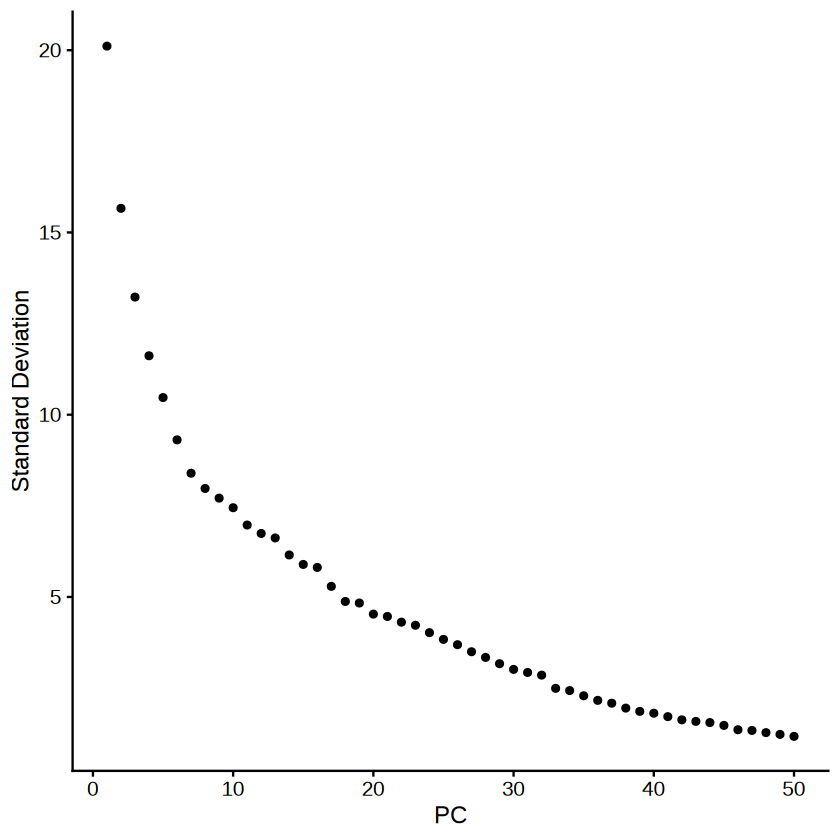

In [ ]:
ElbowPlot(satac_selected, reduction = "pca", ndims = 50)

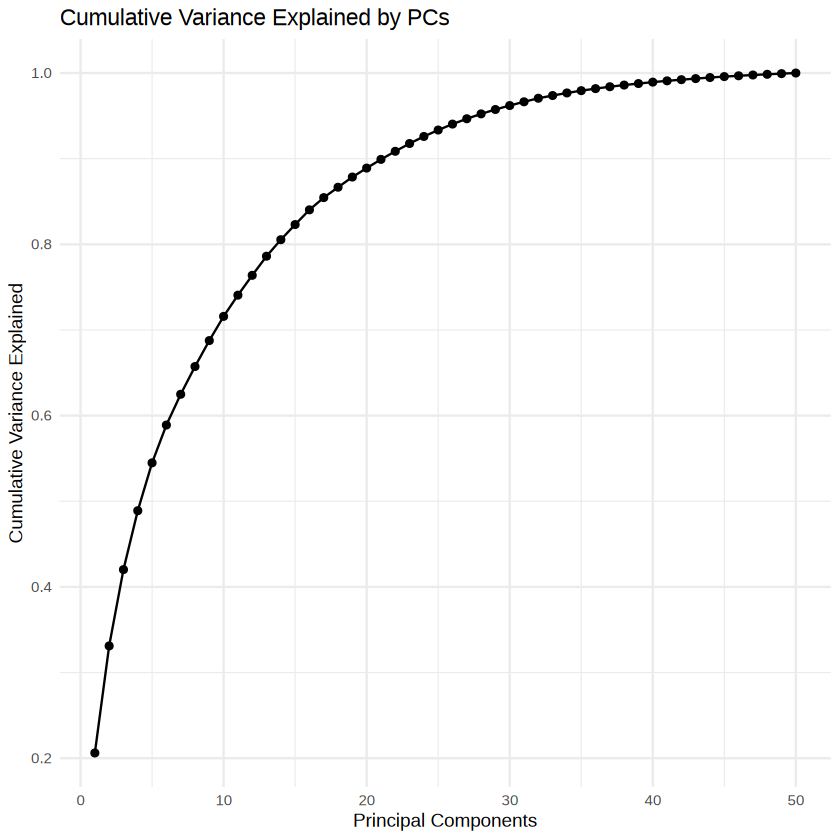

In [ ]:
# Extract standard deviations of PCs
pca_stdev <- satac_selected@reductions$pca@stdev

# Compute variance explained per PC
variance_explained <- (pca_stdev^2) / sum(pca_stdev^2)

# Compute cumulative variance
cumulative_variance <- cumsum(variance_explained)

# Create data frame
var_df <- data.frame(PC = 1:length(cumulative_variance), 
                     Variance = cumulative_variance)

# Plot
library(ggplot2)
ggplot(var_df, aes(x = PC, y = Variance)) +
  geom_point() + geom_line() +
  xlab("Principal Components") + ylab("Cumulative Variance Explained") +
  ggtitle("Cumulative Variance Explained by PCs") +
  theme_minimal()


In [ ]:
satac_selected <- satac_selected %>%
  RunUMAP(dims = 1:25) %>%
  FindNeighbors(dims = 1:25) %>%
  FindClusters(resolution = 0.4)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
11:09:22 UMAP embedding parameters a = 0.9922 b = 1.112

11:09:22 Read 9866 rows and found 25 numeric columns

11:09:22 Using Annoy for neighbor search, n_neighbors = 30

11:09:22 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:09:23 Writing NN index file to temp file /tmp/RtmpS2Wisj/file17a4e628a097e7

11:09:23 Searching Annoy index using 1 thread, search_k = 3000

11:09:26 Annoy recall = 100%

11:09:27 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9866
Number of edges: 289621

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8031
Number of communities: 5
Elapsed time: 1 seconds


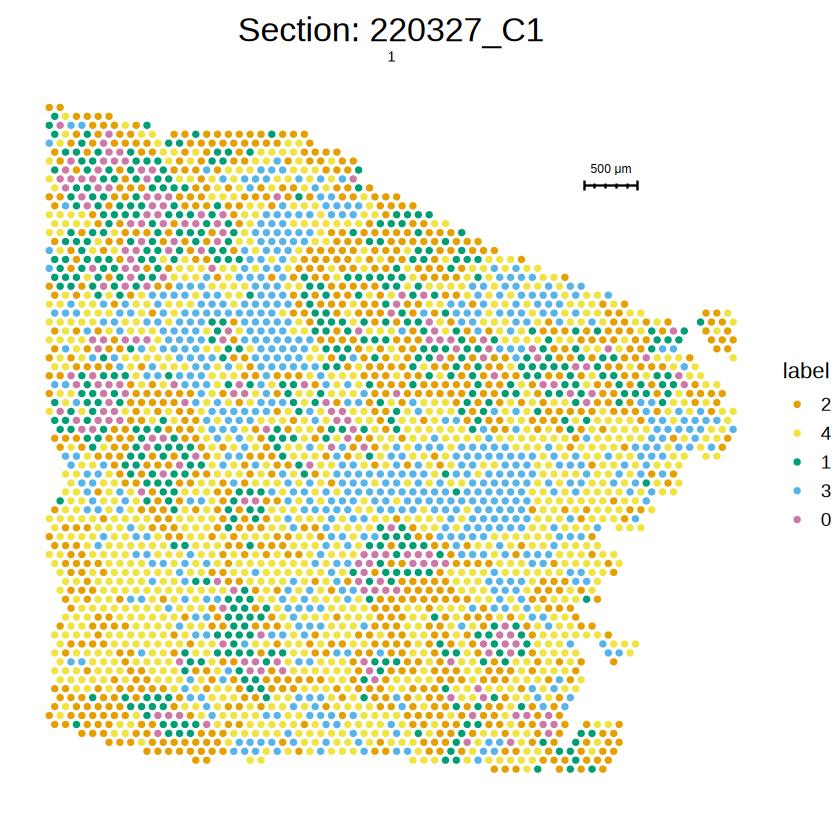

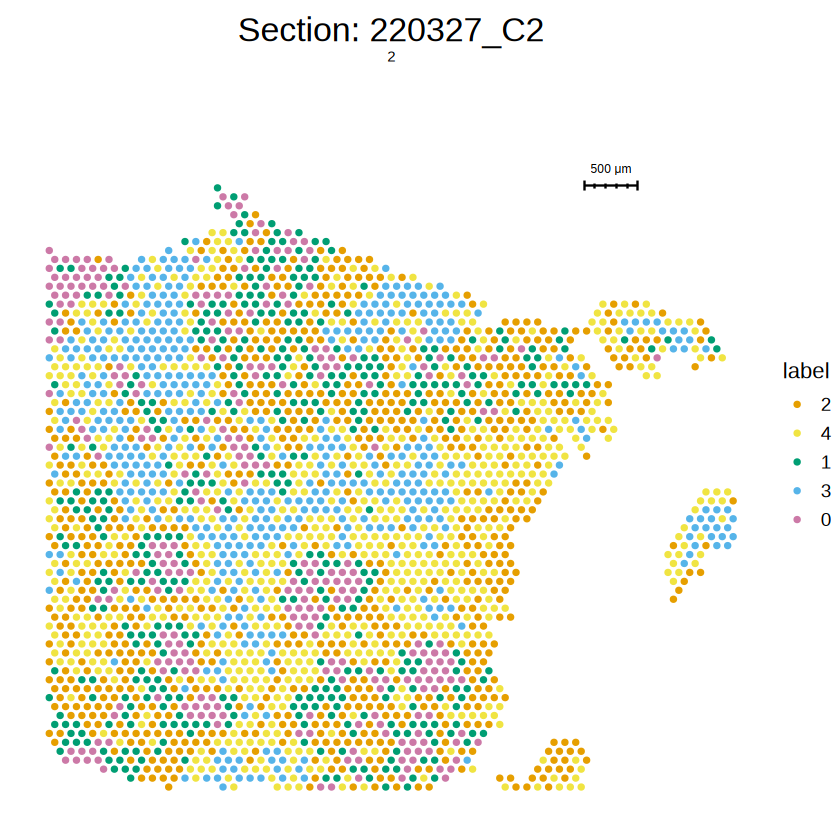

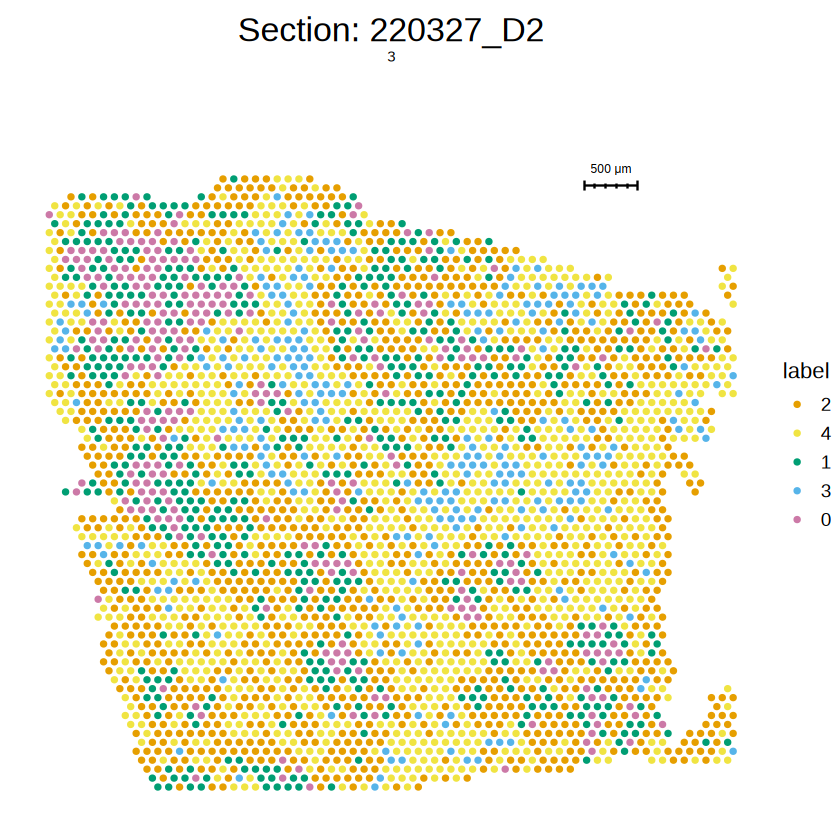

In [ ]:
for (sec in unique(satac_selected$section)) {
    p <- ST.FeaturePlot(subset(satac_selected, section == sec), 
                        features = "peaks_snn_res.0.5", 
                        cols = colors_okate,
                        pt.size = 1.8) +
         ggtitle(paste("Section:", sec)) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
    # plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

In [ ]:
satac_selected

An object of class Seurat 
274167 features across 9866 samples within 4 assays 
Active assay: SCT (19282 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: peaks, RNA, RNA_dca
 3 dimensional reductions calculated: lsi, umap, pca